C:\Users\ZaulT\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


   Age  Income  Student  Purchased
0   22   15000        1          0
1   25   30000        1          0
2   47   60000        0          1
3   52   80000        0          1
4   46   75000        0          1
5   56   90000        0          1
6   28   25000        1          0
7   35   50000        1          1
8   40   65000        0          1
9   50   85000        0          1
(10, 4)
Predicted values
[1 0]
Actual values
[1 0]
Accuracy: 1.0
Confusion Matrix:
[[1 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Feature Importance:
Age : 0.0
Income : 1.0
Student : 0.0


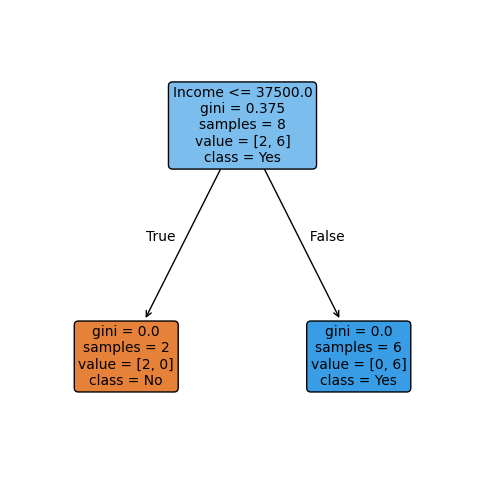

In [1]:
#Decision Tree

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = {
    "Age": [22, 25, 47, 52, 46, 56, 28, 35, 40, 50],
    "Income": [15000, 30000, 60000, 80000, 75000, 90000, 25000, 50000, 65000, 85000],
    "Student": [1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    "Purchased": [0, 0, 1, 1, 1, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

print(df)
print(df.shape)

X = df[["Age", "Income", "Student"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted values")
print(y_pred)

print("Actual values")
print(y_test.values)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

importance = model.feature_importances_

print("Feature Importance:")
for feature, score in zip(X.columns, importance):
    print(feature, ":", round(score, 3))

plt.figure(figsize=(6, 6))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()